# Sanity-check разметки интентов

**Цель ноутбука.** Выполнить базовый sanity-check ручной разметки интентов русскоязычных диалогов из датасета `d0rj/dialogsum-ru` в рамках магистерской диссертации «Семантический анализ русскоязычных диалогов для задачи распознавания намерений с улучшением на базе предобученных моделей».

**Что делает ноутбук:**

- подключает Google Drive в среде Google Colab;
- загружает размеченный CSV `dialogue_intent_annotation_1246_v1_annotated.csv` с Google Drive;
- считает общее число размеченных диалогов;
- анализирует распределение значений `primary_intent`;
- проверяет дисбаланс классов;
- сохраняет таблицу распределения в `results/tables` и график в `results/figures` на Google Drive.

Ноутбук **не обучает модели** и **не модифицирует исходный размеченный CSV**.
Ноутбук рассчитан на запуск в Google Colab.

## 1. Подключение Google Drive и пути к артефактам

In [1]:
import os

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/russian-dialogue-intent-thesis"
DATA_DIR = f"{BASE_DIR}/data"
ANNO_DIR = f"{DATA_DIR}/annotation"
RESULTS_DIR = f"{BASE_DIR}/results"
TABLES_DIR = f"{RESULTS_DIR}/tables"
FIGURES_DIR = f"{RESULTS_DIR}/figures"

os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"ANNO_DIR:    {ANNO_DIR}")
print(f"TABLES_DIR:  {TABLES_DIR}")
print(f"FIGURES_DIR: {FIGURES_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ANNO_DIR:    /content/drive/MyDrive/russian-dialogue-intent-thesis/data/annotation
TABLES_DIR:  /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables
FIGURES_DIR: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/figures


## 2. Импорт библиотек

In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 3. Загрузка размеченного CSV

Файл с ручной разметкой лежит на Google Drive в `data/annotation/`. Ноутбук только читает этот файл и **не вносит в него изменений**.

In [3]:
ANNOTATED_CSV = f"{ANNO_DIR}/dialogue_intent_annotation_1246_v1_annotated.csv"

df = pd.read_csv(ANNOTATED_CSV)

print(f"Число строк: {len(df)}")
print(f"Столбцы: {list(df.columns)}")
df.head()

Число строк: 1246
Столбцы: ['dialog_id', 'split', 'dialogue', 'summary', 'n_utterances', 'dialogue_words', 'summary_words', 'primary_intent', 'secondary_intent', 'is_ambiguous', 'annotation_notes', 'annotator', 'label_version']


,dialog_id,split,dialogue,summary,n_utterances,dialogue_words,summary_words,primary_intent,secondary_intent,is_ambiguous,annotation_notes,annotator,label_version
0,train_6,train,#Person1#: Ну вот.\n#Person2#: Спасибо. Скольк...,#Person1# сообщает #Person2# стоимость поездки...,6,38,7,финансовый_вопрос,NaN,0,NaN,Vladislav,v1
1,train_9,train,"#Person1#: Извините, вы не знаете, где визовый...",#Person1# проходит собеседование с визовым чин...,11,75,14,интервью_или_собеседование,NaN,0,NaN,Vladislav,v1
2,train_18,train,"#Person1#: Ого, посмотри на все эти варианты м...",#Person1# и #Person2# говорят о разных вариант...,10,72,12,бытовое_обсуждение,NaN,0,NaN,Vladislav,v1
3,train_27,train,"#Person1#: Мистер Уайт, я хотел бы сообщить ва...","Джессика говорит мистеру Уайту, что уходит, по...",6,115,21,интервью_или_собеседование,обсуждение_работы_или_учебы,0,NaN,Vladislav,v1
4,train_35,train,#Person1#: Я устал смотреть телевизор. Пойдем ...,"#Person1# устал смотреть телевизор, поэтому #P...",19,217,32,обсуждение_досуга,NaN,0,NaN,Vladislav,v1


## 4. Подсчёт общего числа размеченных диалогов

In [4]:
N = len(df)

# Считаем строки с непустым primary_intent
if "primary_intent" not in df.columns:
    raise KeyError("В CSV отсутствует столбец 'primary_intent' — проверьте файл разметки.")

non_empty_mask = df["primary_intent"].notna() & (df["primary_intent"].astype(str).str.strip() != "")
n_annotated = int(non_empty_mask.sum())
n_missing = N - n_annotated

print(f"Всего строк в файле:                 {N}")
print(f"Размечено (непустой primary_intent): {n_annotated}")
print(f"Без разметки primary_intent:         {n_missing}")

Всего строк в файле:                 1246
Размечено (непустой primary_intent): 1246
Без разметки primary_intent:         0


## 5. Распределение классов `primary_intent`

Считаем количество и долю каждого класса, сортируем по убыванию частоты и сохраняем таблицу в `results/tables/primary_intent_distribution.csv`.

In [5]:
counts = df.loc[non_empty_mask, "primary_intent"].value_counts()

dist_df = (
    counts.rename("count")
    .reset_index()
    .rename(columns={"index": "primary_intent"})
)
# В новых pandas value_counts().reset_index() уже даёт колонку 'primary_intent';
# на всякий случай нормализуем имена столбцов:
if dist_df.columns[0] != "primary_intent":
    dist_df.columns = ["primary_intent", "count"]

dist_df["proportion"] = dist_df["count"] / dist_df["count"].sum()
dist_df = dist_df.sort_values("count", ascending=False).reset_index(drop=True)

dist_csv_path = f"{TABLES_DIR}/primary_intent_distribution.csv"
dist_df.to_csv(dist_csv_path, index=False)

print(f"Таблица сохранена: {dist_csv_path}")
dist_df

Таблица сохранена: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/primary_intent_distribution.csv


,primary_intent,count,proportion
0,личное_общение,248,0.199037
1,обсуждение_работы_или_учебы,143,0.114767
2,обсуждение_путешествия,117,0.093900
3,покупка_или_заказ,102,0.081862
4,совет_или_рекомендация,91,0.073034
5,обсуждение_досуга,87,0.069823
6,бытовое_обсуждение,66,0.052970
7,сервисное_обращение,63,0.050562
8,жалоба_или_проблема,61,0.048957
9,интервью_или_собеседование,50,0.040128


## 6. Визуализация распределения

Строим барплот по числу примеров на класс, подписываем столбцы количеством и долей, сохраняем PNG в `results/figures/primary_intent_distribution.png`.

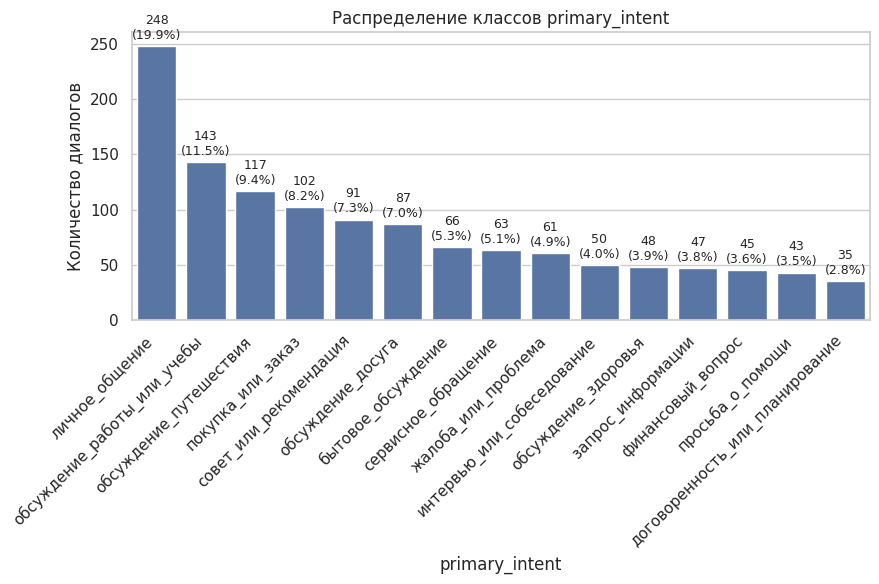

График сохранён: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/figures/primary_intent_distribution.png


In [6]:
fig, ax = plt.subplots(figsize=(max(8, 0.6 * len(dist_df)), 6))

sns.barplot(
    data=dist_df,
    x="primary_intent",
    y="count",
    order=dist_df["primary_intent"].tolist(),
    color="#4C72B0",
    ax=ax,
)

ax.set_title("Распределение классов primary_intent")
ax.set_xlabel("primary_intent")
ax.set_ylabel("Количество диалогов")

for label in ax.get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment("right")

# Подписи над столбцами: count (доля)
for patch, (_, row) in zip(ax.patches, dist_df.iterrows()):
    height = patch.get_height()
    ax.annotate(
        f"{int(row['count'])}\n({row['proportion']:.1%})",
        xy=(patch.get_x() + patch.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()

fig_path = f"{FIGURES_DIR}/primary_intent_distribution.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"График сохранён: {fig_path}")

## 7. Текстовый отчёт о дисбалансе классов

Печатаем краткую сводку: самый частый класс, классы с малой частотой (`count < 10`), классы с долей выше 0.4 и 0.5, и рекомендацию по метрикам.

In [9]:
top_row = dist_df.iloc[0]
top_class = top_row["primary_intent"]
top_prop = float(top_row["proportion"])
top_count = int(top_row["count"])

rare_classes = dist_df[dist_df["count"] < 10]
high_04 = dist_df[dist_df["proportion"] > 0.4]
high_05 = dist_df[dist_df["proportion"] > 0.5]

min_count = int(dist_df["count"].min()) if len(dist_df) else 0
max_prop = float(dist_df["proportion"].max()) if len(dist_df) else 0.0

print("=== Краткий отчёт по распределению primary_intent ===")
print(f"Размечено диалогов:          {n_annotated}")
print(f"Число уникальных классов:    {len(dist_df)}")
print(f"Самый частый класс:          {top_class} (count={top_count}, доля={top_prop:.1%})")
print(f"Минимальный count по классу: {min_count}")
print(f"Максимальная доля по классу: {max_prop:.1%}")

print()
print(f"Классы с count < 10 (всего {len(rare_classes)}):")
if len(rare_classes):
    for _, row in rare_classes.iterrows():
        print(f"  - {row['primary_intent']}: count={int(row['count'])}, доля={row['proportion']:.1%}")
else:
    print("  (нет)")

print()
print(f"Классы с долей > 0.4 (всего {len(high_04)}):")
if len(high_04):
    for _, row in high_04.iterrows():
        print(f"  - {row['primary_intent']}: доля={row['proportion']:.1%}")
else:
    print("  (нет)")

print()
print(f"Классы с долей > 0.5 (всего {len(high_05)}):")
if len(high_05):
    for _, row in high_05.iterrows():
        print(f"  - {row['primary_intent']}: доля={row['proportion']:.1%}")
else:
    print("  (нет)")

print()
print("=== Рекомендация ===")
imbalanced = (max_prop > 0.4) or (min_count < 10)
if imbalanced:
    print(
        "Датасет существенно несбалансирован (есть класс с долей > 40% "
        "и/или класс с count < 10).\n"
        "Для многоклассовой классификации рекомендуется использовать macro-F1 "
        "как основную метрику и применять веса классов (class weights) "
        "или иные техники компенсации дисбаланса при обучении."
    )
else:
    print(
        "Датасет приблизительно сбалансирован (нет класса с долей > 40% "
        "и минимальный count >= 10).\n"
        "Тем не менее, для многоклассовой классификации рекомендуется "
        "наряду с accuracy сообщать macro-F1."
    )


=== Краткий отчёт по распределению primary_intent ===
Размечено диалогов:          1246
Число уникальных классов:    15
Самый частый класс:          личное_общение (count=248, доля=19.9%)
Минимальный count по классу: 35
Максимальная доля по классу: 19.9%

Классы с count < 10 (всего 0):
  (нет)

Классы с долей > 0.4 (всего 0):
  (нет)

Классы с долей > 0.5 (всего 0):
  (нет)

=== Рекомендация ===
Датасет приблизительно сбалансирован (нет класса с долей > 40% и минимальный count >= 10).
Тем не менее, для многоклассовой классификации рекомендуется наряду с accuracy сообщать macro-F1.


## 8. Анализ неоднозначных размеченных диалогов (`is_ambiguous`)

Если в файле разметки присутствует столбец `is_ambiguous`, считаем число диалогов с `is_ambiguous == 1` и смотрим, какие классы `primary_intent` среди них встречаются чаще всего.

In [8]:
if "is_ambiguous" in df.columns:
    amb_series = pd.to_numeric(df["is_ambiguous"], errors="coerce")
    amb_mask = (amb_series == 1) & non_empty_mask
    n_ambiguous = int(amb_mask.sum())

    print(f"Число строк с is_ambiguous == 1 (и непустым primary_intent): {n_ambiguous}")

    if n_ambiguous > 0:
        amb_counts = (
            df.loc[amb_mask, "primary_intent"]
            .value_counts()
            .rename("count")
            .reset_index()
        )
        if amb_counts.columns[0] != "primary_intent":
            amb_counts.columns = ["primary_intent", "count"]
        amb_counts["proportion_within_ambiguous"] = amb_counts["count"] / amb_counts["count"].sum()

        print("\nРаспределение primary_intent среди неоднозначных диалогов:")
        display(amb_counts)
    else:
        print("Неоднозначных размеченных диалогов нет.")
else:
    print("Столбец 'is_ambiguous' отсутствует — раздел пропускается.")

Число строк с is_ambiguous == 1 (и непустым primary_intent): 315

Распределение primary_intent среди неоднозначных диалогов:


,primary_intent,count,proportion_within_ambiguous
0,личное_общение,148,0.469841
1,обсуждение_работы_или_учебы,32,0.101587
2,покупка_или_заказ,24,0.076190
3,обсуждение_путешествия,19,0.060317
4,обсуждение_здоровья,16,0.050794
5,сервисное_обращение,15,0.047619
6,договоренность_или_планирование,13,0.041270
7,бытовое_обсуждение,12,0.038095
8,запрос_информации,9,0.028571
9,финансовый_вопрос,9,0.028571


## 9. Итог: созданные файлы и интерпретация

**При запуске ноутбука на Google Drive создаются файлы:**

- `results/tables/primary_intent_distribution.csv` — таблица распределения классов `primary_intent` (`primary_intent`, `count`, `proportion`).
- `results/figures/primary_intent_distribution.png` — барплот распределения классов.

Артефакты сохраняются на Google Drive 

Этот sanity-check показывает, что разметка по primaryintent в целом полная и качественная, но распределение классов заметно несбалансировано. Все 1246 диалогов имеют непустой primaryintent, то есть пропусков целевой метки нет, и датасет можно целиком использовать для обучения и валидации. При этом всего выделено 15 различных интентов, самый частый класс покрывает около 20% данных, а в хвосте есть несколько классов с числом примеров меньше 10. Такое распределение нельзя назвать экстремальным (нет одного «мусорного» класса на половину выборки), но оно явно имеет «длинный хвост» редких категорий, что потенциально делает задачу сложной для моделей, оптимизируемых только по accuracy.

Отдельно выделены 315 «амбивалентных» диалогов (isambiguous == 1), и внутри этого поднабора распределение ещё более перекошено: почти половина примеров принадлежит одному интенту. Это говорит о том, что часть классов по своей природе размазана и часто вызывает сомнения при разметке. Такие случаи разумно анализировать отдельно (например, строить модели и метрики как на полной выборке, так и на «clean» подвыборке без амбивалентных примеров), а также использовать эту информацию в разделе об ограничениях разметки и сложности постановки задачи.

В целом, по результатам sanity-check можно сделать два практических вывода для дальнейших экспериментов: (1) базовая постановка по primaryintent корректна, и разметка пригодна для обучения; (2) из‑за дисбаланса классов и наличия редких и амбивалентных категорий при оценке моделей необходимо опираться не только на accuracy, но и на макро‑F1 (и/или взвешенный F1), а в самих моделях имеет смысл использовать стратегии работы с дисбалансом (веса классов, пере/недосэмплинг, отдельный анализ по хвостовым классам).